# Chapter 1 Hands-On: Analyzing the FineWeb Dataset

**Goal:** Understand what real pre-training data looks like — the good, the bad, and the garbage.

We'll:
1. Download a small sample of FineWeb (HuggingFace's 15T token English web dataset)
2. Explore the structure — what fields exist and what they mean
3. Find examples of "clean" vs "dirty" data
4. Measure noise ratio using simple heuristics
5. Understand why 80-95% of raw web data gets thrown away

## Step 1: Download a FineWeb Sample

FineWeb is ~15 trillion tokens. We'll grab just a tiny slice (`sample-10BT` = 10 billion token sample) and only load a small portion of that.

In [1]:
from datasets import load_dataset

# Load a small streaming sample — this won't download the full dataset
# FineWeb sample-10BT is a curated 10B token subset
ds = load_dataset(
    "HuggingFaceFW/fineweb",
    name="sample-10BT",
    split="train",
    streaming=True  # Stream instead of downloading everything
)

# Take first 5000 documents — enough to see patterns without waiting forever
samples = list(ds.take(5000))
print(f"Loaded {len(samples)} documents")
print(f"\nFields in each document: {list(samples[0].keys())}")

/home/mkandreg/data_engineering_projects/de_for_llms/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 5000 documents

Fields in each document: ['text', 'id', 'dump', 'url', 'date', 'file_path', 'language', 'language_score', 'token_count']


## Step 2: Explore the Data Structure

Let's see what metadata FineWeb provides per document and look at a few examples.

In [2]:
import pandas as pd

df = pd.DataFrame(samples)
print("=== Dataset Shape ===")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
print(f"\n=== Columns ===")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")

print(f"\n=== First Document ===")
for key, value in samples[0].items():
    if key == 'text':
        print(f"  {key}: {value[:200]}...")
    else:
        print(f"  {key}: {value}")

=== Dataset Shape ===
Rows: 5000, Columns: 9

=== Columns ===
  text: str
  id: str
  dump: str
  url: str
  date: str
  file_path: str
  language: str
  language_score: float64
  token_count: int64

=== First Document ===
  text: |Viewing Single Post From: Spoilers for the Week of February 11th|
|Lil||Feb 1 2013, 09:58 AM|
Don't care about Chloe/Taniel/Jen-Jen. Don't care about Sami, really, but hoping that we get some good "S...
  id: <urn:uuid:39147604-bfbe-4ed5-b19c-54105f8ae8a7>
  dump: CC-MAIN-2013-20
  url: http://daytimeroyaltyonline.com/single/?p=8906650&t=8780053
  date: 2013-05-18T05:48:59Z
  file_path: s3://commoncrawl/crawl-data/CC-MAIN-2013-20/segments/1368696381249/warc/CC-MAIN-20130516092621-00000-ip-10-60-113-184.ec2.internal.warc.gz
  language: en
  language_score: 0.8232095837593079
  token_count: 142


In [3]:
# Add useful derived columns
df['text_length'] = df['text'].str.len()  # character count
df['word_count'] = df['text'].str.split().str.len()  # word count
df['line_count'] = df['text'].str.count('\n') + 1  # line count

print("=== Basic Text Statistics ===")
print(df[['text_length', 'word_count', 'line_count']].describe().round(1))

=== Basic Text Statistics ===
       text_length  word_count  line_count
count       5000.0      5000.0      5000.0
mean        3026.4       511.6        16.7
std         5358.9       917.3        41.8
min          136.0        24.0         1.0
25%          853.8       143.0         5.0
50%         1731.5       290.0         9.0
75%         3418.8       578.2        17.0
max       116723.0     20945.0      1247.0


## Step 3: What Does "Clean" vs "Dirty" Data Look Like?

FineWeb is *already filtered* — it's a cleaned dataset. But even cleaned data has varying quality.

Let's define some simple heuristic quality signals and see the spectrum.

In [4]:
import re

def quality_signals(text):
    """Compute simple quality heuristics for a text document."""
    words = text.split()
    lines = text.split('\n')
    chars = len(text)
    
    if not words or not chars:
        return {k: 0 for k in [
            'avg_word_length', 'uppercase_ratio',
            'special_char_ratio', 'duplicate_line_ratio',
            'short_line_ratio', 'url_density', 'alpha_ratio'
        ]}
    
    # Average word length — too short = abbreviations/codes, too long = URLs/garbage
    avg_word_len = sum(len(w) for w in words) / len(words)
    
    # Uppercase ratio — high = ALL CAPS SPAM
    upper_chars = sum(1 for c in text if c.isupper())
    alpha_chars = sum(1 for c in text if c.isalpha())
    uppercase_ratio = upper_chars / alpha_chars if alpha_chars > 0 else 0
    
    # Special character ratio — high = code, HTML remnants, or garbage
    special_chars = sum(1 for c in text if not c.isalnum() and not c.isspace())
    special_ratio = special_chars / chars
    
    # Duplicate lines — high = boilerplate/templates
    non_empty_lines = [l.strip() for l in lines if l.strip()]
    unique_lines = set(non_empty_lines)
    dup_ratio = 1 - (len(unique_lines) / len(non_empty_lines)) if non_empty_lines else 0
    
    # Short lines ratio — high = lists, menus, navigation (not prose)
    short_lines = sum(1 for l in non_empty_lines if len(l.split()) < 5)
    short_ratio = short_lines / len(non_empty_lines) if non_empty_lines else 0
    
    # URL density — high = link farms, spam
    urls = re.findall(r'https?://\S+', text)
    url_density = len(urls) / len(words)
    
    # Alphabetic ratio — low = numbers/symbols heavy
    alpha_ratio = alpha_chars / chars
    
    return {
        'avg_word_length': round(avg_word_len, 2),
        'uppercase_ratio': round(uppercase_ratio, 3),
        'special_char_ratio': round(special_ratio, 3),
        'duplicate_line_ratio': round(dup_ratio, 3),
        'short_line_ratio': round(short_ratio, 3),
        'url_density': round(url_density, 4),
        'alpha_ratio': round(alpha_ratio, 3),
    }

# Compute signals for all documents
signals = pd.DataFrame([quality_signals(row['text']) for _, row in df.iterrows()])

# Drop signal columns from df if they already exist (safe for re-runs)
existing_signal_cols = [c for c in signals.columns if c in df.columns]
if existing_signal_cols:
    df = df.drop(columns=existing_signal_cols)

df = pd.concat([df, signals], axis=1)

print("=== Quality Signal Statistics ===")
print(signals.describe().round(3))

=== Quality Signal Statistics ===
       avg_word_length  uppercase_ratio  special_char_ratio  \
count         5000.000         5000.000            5000.000   
mean             4.968            0.053               0.032   
std              0.498            0.033               0.013   
min              3.660            0.000               0.005   
25%              4.620            0.032               0.024   
50%              4.920            0.045               0.030   
75%              5.250            0.064               0.037   
max              8.340            0.431               0.152   

       duplicate_line_ratio  short_line_ratio  url_density  alpha_ratio  
count              5000.000          5000.000     5000.000     5000.000  
mean                  0.001             0.116        0.000        0.787  
std                   0.009             0.155        0.002        0.026  
min                   0.000             0.000        0.000        0.609  
25%                   0.000 

In [5]:
# Create a simple composite quality score (0-100)
# Higher = more likely to be clean natural language prose
def quality_score(row):
    score = 100
    
    # Penalize very short documents (< 50 words)
    if row['word_count'] < 50:
        score -= 30
    elif row['word_count'] < 100:
        score -= 15
    
    # Penalize high uppercase ratio (> 20% = likely spam/shouting)
    if row['uppercase_ratio'] > 0.2:
        score -= 20
    
    # Penalize high special character ratio (> 15% = code/html remnants)
    if row['special_char_ratio'] > 0.15:
        score -= 20
    elif row['special_char_ratio'] > 0.10:
        score -= 10
    
    # Penalize high duplicate lines (> 30% = boilerplate heavy)
    if row['duplicate_line_ratio'] > 0.3:
        score -= 15
    
    # Penalize mostly short lines (> 60% = lists/menus, not prose)
    if row['short_line_ratio'] > 0.6:
        score -= 15
    
    # Penalize high URL density
    if row['url_density'] > 0.05:
        score -= 15
    
    # Penalize low alphabetic content
    if row['alpha_ratio'] < 0.5:
        score -= 20
    
    return max(0, score)

df['quality_score'] = df.apply(quality_score, axis=1)

print("=== Quality Score Distribution ===")
print(df['quality_score'].describe().round(1))
print(f"\n=== Quality Tiers ===")
print(f"  High quality (80-100):  {(df['quality_score'] >= 80).sum()} docs ({(df['quality_score'] >= 80).mean()*100:.1f}%)")
print(f"  Medium quality (50-79): {((df['quality_score'] >= 50) & (df['quality_score'] < 80)).sum()} docs ({((df['quality_score'] >= 50) & (df['quality_score'] < 80)).mean()*100:.1f}%)")
print(f"  Low quality (0-49):     {(df['quality_score'] < 50).sum()} docs ({(df['quality_score'] < 50).mean()*100:.1f}%)")

=== Quality Score Distribution ===
count    5000.0
mean       97.5
std         6.4
min        50.0
25%       100.0
50%       100.0
75%       100.0
max       100.0
Name: quality_score, dtype: float64

=== Quality Tiers ===
  High quality (80-100):  4920 docs (98.4%)
  Medium quality (50-79): 80 docs (1.6%)
  Low quality (0-49):     0 docs (0.0%)


## Step 4: See Real Examples — Best vs Worst

Let's look at what high-quality and low-quality documents actually look like.

In [7]:
# Show top 3 highest quality documents
print("=" * 80)
print("TOP 3 HIGHEST QUALITY DOCUMENTS")
print("=" * 80)

top = df.nlargest(3, 'quality_score')
for i, (_, row) in enumerate(top.iterrows(), 1):
    print(f"\n--- Document {i} (score: {row['quality_score']}, words: {row['word_count']}) ---")
    print(f"URL: {row.get('url', 'N/A')}")
    # Show first 500 chars
    print(row['text'][:500])
    print("...")

TOP 3 HIGHEST QUALITY DOCUMENTS

--- Document 1 (score: 100, words: 535) ---
URL: http://endogenousretrovirus.blogspot.com/2007/11/if-you-have-set-yourself-on-fire-do-not.html?showComment=1196270520000
*sigh* Fundamentalist community, let me pass on some advice to you I learned from the atheistic community:
If you have set yourself on fire, do not run.
Okay? Okay?? Please?
Look, D, you had two months to say to Harvard in private emails, "Im sorry, I shouldnt have been using that animation in my paid presentations. I wont use it again. I really do like 'Inner Life', though, and would love to use it in classroom presentations, from the BioVisions site, if that is acceptable."
I sat here, for two
...

--- Document 2 (score: 100, words: 407) ---
URL: http://news.cancerconnect.com/
A novel two-step immunotherapy approach has shown clinically beneficial responses in patients with advanced ovarian cancer. Following Lifestyle Recommendations Reduces Risk of Cancer Death
People who follow the d

In [8]:
# Show bottom 3 lowest quality documents
print("=" * 80)
print("BOTTOM 3 LOWEST QUALITY DOCUMENTS")
print("=" * 80)

bottom = df.nsmallest(3, 'quality_score')
for i, (_, row) in enumerate(bottom.iterrows(), 1):
    print(f"\n--- Document {i} (score: {row['quality_score']}, words: {row['word_count']}) ---")
    print(f"URL: {row.get('url', 'N/A')}")
    print(f"Signals: uppercase={row['uppercase_ratio']:.1%}, special={row['special_char_ratio']:.1%}, "
          f"dup_lines={row['duplicate_line_ratio']:.1%}, short_lines={row['short_line_ratio']:.1%}")
    print(row['text'][:500])
    print("...")

BOTTOM 3 LOWEST QUALITY DOCUMENTS

--- Document 1 (score: 50, words: 41) ---
URL: http://www.vegasmeansbusiness.com/meeting-facilities/restaurants-and-alternate-venues/?maxshow=25&fieldid=0&efilter=zzzz&sfilter=a&regionid=0&subcatid=377&catid=181&startrow=1
Signals: uppercase=22.4%, special=4.2%, dup_lines=0.0%, short_lines=50.0%
Sometimes, the best place to meet isn't in a meeting room. Check out these alternative meeting spaces.
© 2016 Las Vegas Convention and Visitors Authority
3150 PARADISE ROAD, LAS VEGAS, NV 89109
About LVCVA |
Contact Us |
Stay Connected |
...

--- Document 2 (score: 50, words: 48) ---
URL: https://secure.pssap.gov.au/aol/empIndex.html
Signals: uppercase=28.7%, special=4.8%, dup_lines=0.0%, short_lines=28.6%
The site is loading, please wait...
About CSC |
PSSap Privacy Notice |
PSSap ABN: 65 127 917 725 RSE: R1004601
CSC ABN: 48 882 817 243 AFSL: 238069 RSEL: L0001397
CSC is the Trustee of the Public Sector Superannuation accumulation plan (PSSap)
Your Governmen

## Step 5: Visualize the Quality Distribution

Let's see the full picture of data quality across our sample.

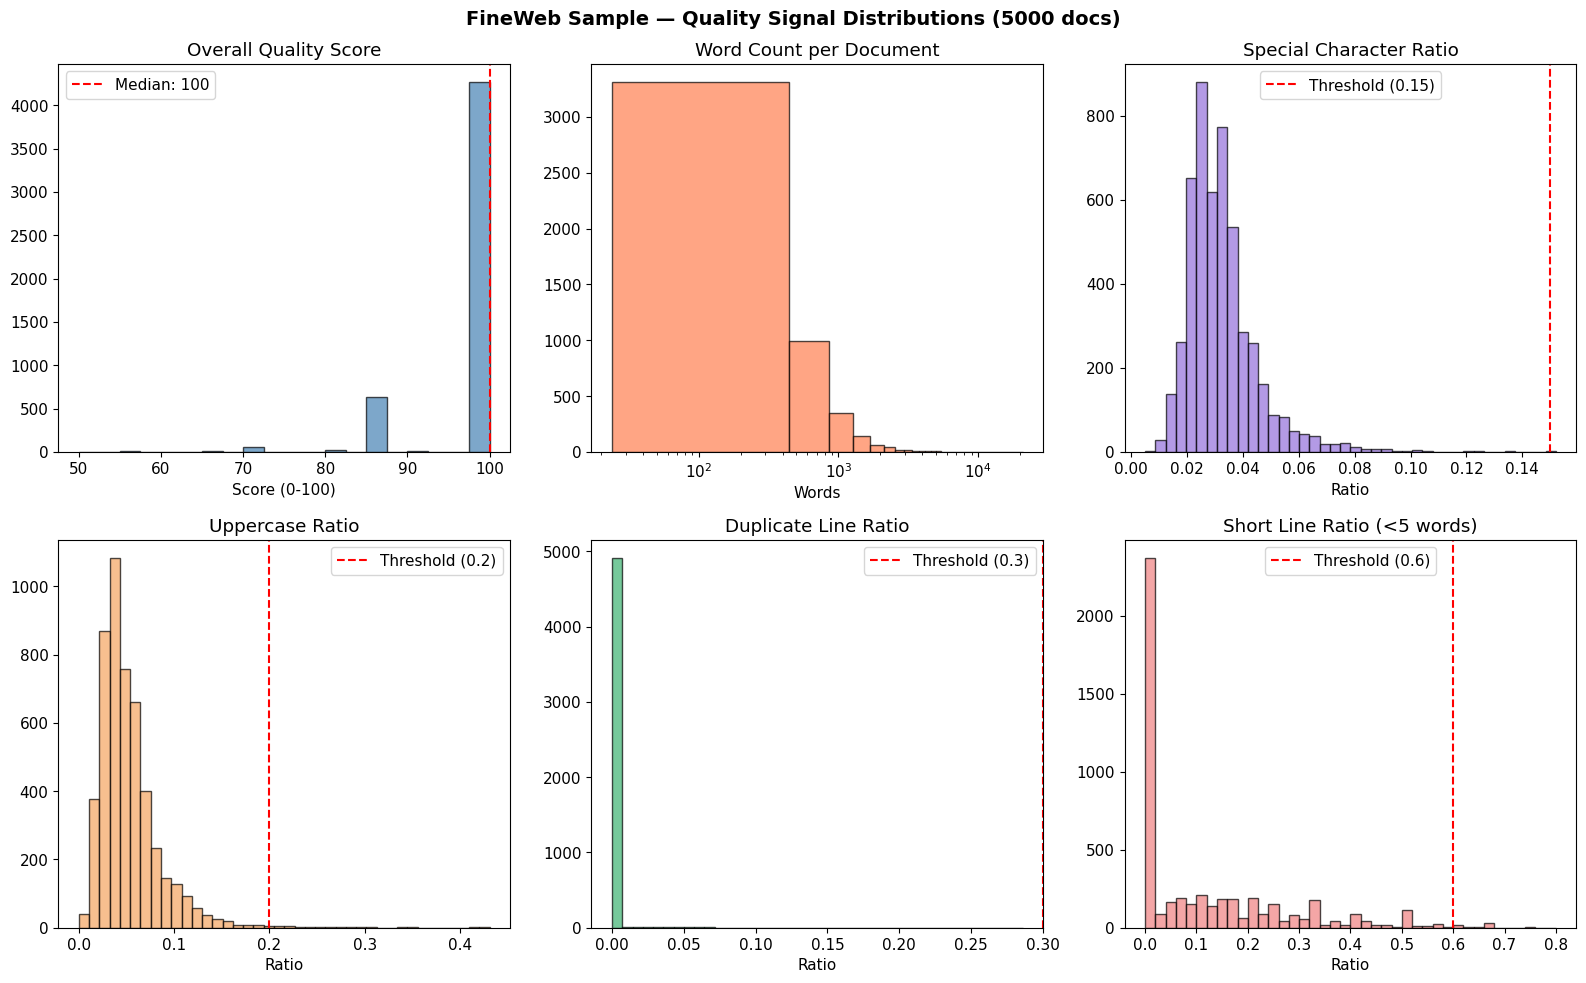

Saved to data/fineweb_quality_distributions.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (14, 10)
matplotlib.rcParams['font.size'] = 11

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('FineWeb Sample — Quality Signal Distributions (5000 docs)', fontsize=14, fontweight='bold')

# Quality score distribution
axes[0, 0].hist(df['quality_score'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Overall Quality Score')
axes[0, 0].set_xlabel('Score (0-100)')
axes[0, 0].axvline(df['quality_score'].median(), color='red', linestyle='--', label=f"Median: {df['quality_score'].median():.0f}")
axes[0, 0].legend()

# Word count distribution (log scale)
axes[0, 1].hist(df['word_count'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Word Count per Document')
axes[0, 1].set_xlabel('Words')
axes[0, 1].set_xscale('log')

# Special character ratio
axes[0, 2].hist(df['special_char_ratio'], bins=40, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Special Character Ratio')
axes[0, 2].set_xlabel('Ratio')
axes[0, 2].axvline(0.15, color='red', linestyle='--', label='Threshold (0.15)')
axes[0, 2].legend()

# Uppercase ratio
axes[1, 0].hist(df['uppercase_ratio'], bins=40, color='sandybrown', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Uppercase Ratio')
axes[1, 0].set_xlabel('Ratio')
axes[1, 0].axvline(0.2, color='red', linestyle='--', label='Threshold (0.2)')
axes[1, 0].legend()

# Duplicate line ratio
axes[1, 1].hist(df['duplicate_line_ratio'], bins=40, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Duplicate Line Ratio')
axes[1, 1].set_xlabel('Ratio')
axes[1, 1].axvline(0.3, color='red', linestyle='--', label='Threshold (0.3)')
axes[1, 1].legend()

# Short line ratio
axes[1, 2].hist(df['short_line_ratio'], bins=40, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Short Line Ratio (<5 words)')
axes[1, 2].set_xlabel('Ratio')
axes[1, 2].axvline(0.6, color='red', linestyle='--', label='Threshold (0.6)')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('../data/fineweb_quality_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to data/fineweb_quality_distributions.png")

## Step 6: Simulate a Filtering Pipeline

Now let's simulate what real pre-training data cleaning looks like.

We'll apply progressively stricter filters and see how much data survives at each stage — this is the "data funnel" from Chapter 1.

In [10]:
total = len(df)

# Stage 1: Remove very short documents (< 50 words)
stage1 = df[df['word_count'] >= 50]

# Stage 2: Remove high special-char content (likely code/html remnants)
stage2 = stage1[stage1['special_char_ratio'] <= 0.15]

# Stage 3: Remove heavy boilerplate (> 30% duplicate lines)
stage3 = stage2[stage2['duplicate_line_ratio'] <= 0.3]

# Stage 4: Remove mostly non-prose (> 60% short lines)
stage4 = stage3[stage3['short_line_ratio'] <= 0.6]

# Stage 5: Remove ALL CAPS spam
stage5 = stage4[stage4['uppercase_ratio'] <= 0.2]

print("=== Data Funnel (Filtering Pipeline) ===")
print(f"{'Stage':<40} {'Docs':>8} {'Survived':>10} {'Of Original':>12}")
print("-" * 72)
print(f"{'Raw sample':.<40} {total:>8} {'100.0%':>10} {'100.0%':>12}")
print(f"{'After: min 50 words':.<40} {len(stage1):>8} {len(stage1)/total*100:>9.1f}% {len(stage1)/total*100:>11.1f}%")
print(f"{'After: special chars <= 15%':.<40} {len(stage2):>8} {len(stage2)/len(stage1)*100:>9.1f}% {len(stage2)/total*100:>11.1f}%")
print(f"{'After: duplicate lines <= 30%':.<40} {len(stage3):>8} {len(stage3)/len(stage2)*100:>9.1f}% {len(stage3)/total*100:>11.1f}%")
print(f"{'After: short lines <= 60%':.<40} {len(stage4):>8} {len(stage4)/len(stage3)*100:>9.1f}% {len(stage4)/total*100:>11.1f}%")
print(f"{'After: uppercase <= 20%':.<40} {len(stage5):>8} {len(stage5)/len(stage4)*100:>9.1f}% {len(stage5)/total*100:>11.1f}%")
print(f"\n=> Final retention: {len(stage5)}/{total} documents ({len(stage5)/total*100:.1f}%)")
print(f"=> Filtered out: {total - len(stage5)} documents ({(total - len(stage5))/total*100:.1f}%)")

=== Data Funnel (Filtering Pipeline) ===
Stage                                        Docs   Survived  Of Original
------------------------------------------------------------------------
Raw sample..............................     5000     100.0%       100.0%
After: min 50 words.....................     4957      99.1%        99.1%
After: special chars <= 15%.............     4956     100.0%        99.1%
After: duplicate lines <= 30%...........     4956     100.0%        99.1%
After: short lines <= 60%...............     4913      99.1%        98.3%
After: uppercase <= 20%.................     4882      99.4%        97.6%

=> Final retention: 4882/5000 documents (97.6%)
=> Filtered out: 118 documents (2.4%)


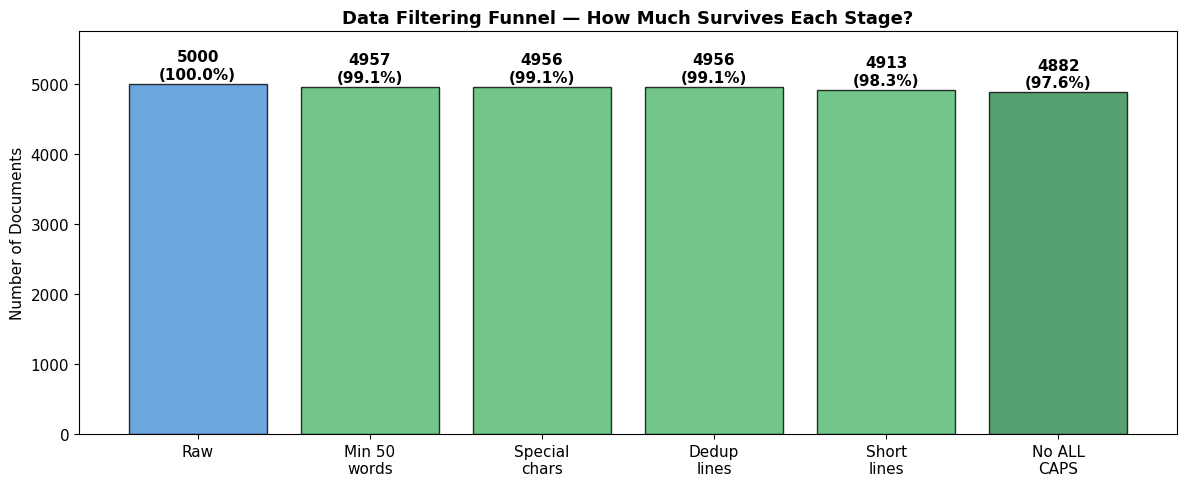

Saved to data/fineweb_filtering_funnel.png


In [11]:
# Visualize the funnel
stages = ['Raw', 'Min 50\nwords', 'Special\nchars', 'Dedup\nlines', 'Short\nlines', 'No ALL\nCAPS']
counts = [total, len(stage1), len(stage2), len(stage3), len(stage4), len(stage5)]
percentages = [c / total * 100 for c in counts]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(stages, counts, color=['#4a90d9', '#50b86c', '#50b86c', '#50b86c', '#50b86c', '#2d8a4e'],
              edgecolor='black', alpha=0.8)

for bar, pct, count in zip(bars, percentages, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

ax.set_title('Data Filtering Funnel — How Much Survives Each Stage?', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Documents')
ax.set_ylim(0, total * 1.15)

plt.tight_layout()
plt.savefig('../data/fineweb_filtering_funnel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to data/fineweb_filtering_funnel.png")

## Step 7: What Got Filtered Out?

Let's look at specific examples that each filter caught — this builds intuition for why each heuristic exists.

In [12]:
# Documents caught by each filter
caught_short = df[df['word_count'] < 50]
caught_special = stage1[stage1['special_char_ratio'] > 0.15]
caught_dup = stage2[stage2['duplicate_line_ratio'] > 0.3]
caught_short_lines = stage3[stage3['short_line_ratio'] > 0.6]

print(f"Documents caught by each filter:")
print(f"  Too short (<50 words): {len(caught_short)}")
print(f"  Too many special chars: {len(caught_special)}")
print(f"  Too many duplicate lines: {len(caught_dup)}")
print(f"  Too many short lines: {len(caught_short_lines)}")

# Show an example from each category
for name, caught in [('TOO SHORT', caught_short), 
                      ('HIGH SPECIAL CHARS', caught_special),
                      ('HIGH DUPLICATE LINES', caught_dup),
                      ('MOSTLY SHORT LINES', caught_short_lines)]:
    if len(caught) > 0:
        example = caught.iloc[0]
        print(f"\n{'=' * 60}")
        print(f"CAUGHT BY: {name}")
        print(f"URL: {example.get('url', 'N/A')}")
        print(f"Words: {example['word_count']}, Special: {example['special_char_ratio']:.1%}, "
              f"Dup lines: {example['duplicate_line_ratio']:.1%}, Short lines: {example['short_line_ratio']:.1%}")
        print(f"{'=' * 60}")
        print(example['text'][:400])
        print("...")

Documents caught by each filter:
  Too short (<50 words): 43
  Too many special chars: 1
  Too many duplicate lines: 0
  Too many short lines: 43

CAUGHT BY: TOO SHORT
URL: http://mail-index.netbsd.org/tech-pkg/2005/02/21/0020.html
Words: 49, Special: 9.4%, Dup lines: 0.0%, Short lines: 20.0%
Subject: Binary updates all installed pkgs? To: None <tech-pkg@NetBSD.org> From: Mark Weinem <firstname.lastname@example.org> List: tech-pkg Date: 02/21/2005 22:20:06
How to update all installed pkgs using binary packages? So, if my
installed packages are from ../packages/pkgsrc-2004Q3 how to update all
of them using the packages from .../packages/pkgsrc-2004Q4?
Regards, Mark Weinem
...

CAUGHT BY: HIGH SPECIAL CHARS
URL: http://forums.comicgenesis.com/viewtopic.php?p=247735
Words: 122, Special: 15.2%, Dup lines: 0.0%, Short lines: 8.3%
Well the panel jam is over. It ended.
The serial kind of just faded out.
Oh well... at least you can read everybody else's comics. Except Pauly, because he doesn't

## Step 8: Key Takeaways

Let's summarize what we learned from this analysis.

In [ ]:
# Final summary statistics
clean = df[df['quality_score'] >= 80]
dirty = df[df['quality_score'] < 50]

print("=" * 60)
print("EXERCISE SUMMARY")
print("=" * 60)
print(f"""
Dataset: FineWeb sample-10BT (already pre-filtered by HuggingFace)
Sample size: {len(df)} documents

Even in this PRE-CLEANED dataset:
  - High quality (score >= 80): {len(clean)} ({len(clean)/len(df)*100:.1f}%)
  - Low quality (score < 50):   {len(dirty)} ({len(dirty)/len(df)*100:.1f}%)
  - Simple 5-filter pipeline kept: {len(stage5)}/{total} ({len(stage5)/total*100:.1f}%)

Key Lessons:
  1. Even "cleaned" datasets have quality variance — always verify
  2. Simple heuristics (word count, special chars, dedup) catch obvious garbage
  3. Each filter is a tradeoff: too strict = lose good data, too loose = keep garbage  
  4. Real pipelines like FineWeb use MUCH more sophisticated filters
     (perplexity scoring, classifier-based filtering, C4-style rules)
  5. The data funnel is real: raw web → 5-20% clean training data

What FineWeb uses that we didn't:
  - Language identification (keep only English)
  - URL-based filtering (block known spam domains)
  - Perplexity scoring with a reference language model  
  - MinHash deduplication (fuzzy near-duplicate removal)
  - Classifier-based quality scoring

Reflection points:
  - On FineWeb (already cleaned), simple heuristics still catch ~2-3%.
    On raw Common Crawl, 80-95% gets thrown away.
  - Low-quality examples are navigation menus, cookie banners, boilerplate
    — exactly what a model would memorize if not filtered.
  - The filter that removes the most documents reveals where the biggest
    quality problems hide in web data.
""")